# Module 4 - Treasury Cash Flow Pattern Analysis

**Objective:** identify weekly treasury stress, quantify uncertainty, and test recurring seasonal behavior using `financials_cleaned.csv`.

**Analytical choices.** Transaction-level cash_flow_usd is summed into Monday-starting weeks. The 13-week rolling mean and standard deviation describe trend and volatility. The notebook reports a true 95% confidence interval for the rolling mean and a separate one-step 95% prediction interval for weekly outcomes. Because no bank-balance or minimum-liquidity field is available, statistical treasury stress is defined without look-ahead: an eligible week is stressed when cash flow falls below the trailing 52-week 10th percentile calculated using prior weeks only.

In [1]:
from pathlib import Path
import warnings, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style='whitegrid', context='notebook')

# Locate the project reliably when an IDE starts the kernel in a different folder.
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'cleaned').is_dir() and (candidate / 'Notebooks').is_dir():
            return candidate
    raise FileNotFoundError(
        'Project root not found. Open this notebook from the Project intership folder '
        'or set ROOT manually to that folder.'
    )

ROOT = find_project_root()
preferred = ROOT / 'data' / 'cleaned' / 'financials_cleaned.csv'
fallback = ROOT / 'data' / 'cleaned' / 'financials_clean.csv'
DATA_PATH = preferred if preferred.exists() else fallback
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Financial dataset not found: {preferred} or {fallback}')
OUT = ROOT / 'Reports' / 'module4_treasury_cash_flow'
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH, parse_dates=['record_date'])
print(f'{len(df):,} records | {df.record_date.min().date()} to {df.record_date.max().date()}')
df[['record_date','cash_flow_usd','transaction_type']].head()

66,000 records | 2021-01-01 to 2024-12-31


,record_date,cash_flow_usd,transaction_type
0,2021-01-01,944763.64,Revenue
1,2021-01-01,27541.31,Revenue
2,2021-01-01,-1300154.76,Operational Expense
3,2021-01-01,-526501.26,COGS
4,2021-01-01,793306.62,Revenue


## 1. Data quality and weekly aggregation

In [2]:
quality = pd.Series({
    'records': len(df), 'start': df.record_date.min(), 'end': df.record_date.max(),
    'missing_cash_flow': df.cash_flow_usd.isna().sum(),
    'duplicate_ids': df.finance_record_id.duplicated().sum(),
    'transaction_types': df.transaction_type.nunique()
})
display(quality.to_frame('value'))

# ISO weeks start on Monday. Reindexing makes absent weeks explicit.
df['week_start'] = df['record_date'] - pd.to_timedelta(df['record_date'].dt.weekday, unit='D')
weekly = df.groupby('week_start').agg(
    cash_flow_usd=('cash_flow_usd','sum'),
    revenue_usd=('revenue_usd','sum'),
    procurement_cost_usd=('procurement_cost_usd','sum'),
    logistics_cost_usd=('logistics_cost_usd','sum'),
    operational_cost_usd=('operational_cost_usd','sum'),
    sla_penalty_usd=('sla_penalty_usd','sum'),
    transactions=('finance_record_id','count'),
    avg_dso=('days_sales_outstanding','mean'),
    avg_dpo=('days_payable_outstanding','mean'),
    avg_cash_conversion_cycle=('cash_conversion_cycle','mean'),
).sort_index()
calendar = pd.date_range(weekly.index.min(), weekly.index.max(), freq='W-MON')
missing_weeks = calendar.difference(weekly.index)
weekly = weekly.reindex(calendar).rename_axis('week_start')
print('Missing calendar weeks:', len(missing_weeks))
display(weekly.head())

,value
records,66000
start,2021-01-01 00:00:00
end,2024-12-31 00:00:00
missing_cash_flow,0
duplicate_ids,0
transaction_types,7


Missing calendar weeks: 0


,cash_flow_usd,revenue_usd,procurement_cost_usd,logistics_cost_usd,operational_cost_usd,sla_penalty_usd,transactions,avg_dso,avg_dpo,avg_cash_conversion_cycle
week_start,,,,,,,,,,
2020-12-28,-4.223467e+07,3375753.68,704522.23,89429.95,49782.02,141044.64,143,57.812727,67.507552,34.851748
2021-01-04,-1.004339e+08,5783960.85,2379382.24,92470.25,118697.68,260684.75,333,58.018559,68.446246,35.950120
2021-01-11,-7.083360e+07,6504290.95,1158727.25,83511.54,143124.28,334612.69,288,57.793021,68.190139,34.892743
2021-01-18,-9.465748e+07,7122501.50,3678435.90,137828.50,118452.15,131639.92,328,59.409207,68.510335,35.478872
2021-01-25,-7.374024e+07,7151075.52,2477488.91,109990.97,170834.21,215392.26,295,59.086915,67.422407,36.182000


## 2. Rolling mean, volatility, and confidence bands

In [3]:
WINDOW = 13
weekly['rolling_mean_13w'] = weekly.cash_flow_usd.rolling(WINDOW, min_periods=WINDOW).mean()
weekly['rolling_std_13w'] = weekly.cash_flow_usd.rolling(WINDOW, min_periods=WINDOW).std(ddof=1)
critical = stats.t.ppf(.975, df=WINDOW-1)
weekly['ci95_lower_mean'] = weekly.rolling_mean_13w - critical * weekly.rolling_std_13w / np.sqrt(WINDOW)
weekly['ci95_upper_mean'] = weekly.rolling_mean_13w + critical * weekly.rolling_std_13w / np.sqrt(WINDOW)
# Prediction intervals describe an individual week and are wider than confidence intervals for the mean.
weekly['pi95_lower'] = weekly.rolling_mean_13w - critical * weekly.rolling_std_13w * np.sqrt(1 + 1/WINDOW)
weekly['pi95_upper'] = weekly.rolling_mean_13w + critical * weekly.rolling_std_13w * np.sqrt(1 + 1/WINDOW)
# One-step forecast diagnostics use prior observations only.
weekly['forecast_mean'] = weekly.cash_flow_usd.shift(1).rolling(WINDOW, min_periods=WINDOW).mean()
weekly['forecast_std'] = weekly.cash_flow_usd.shift(1).rolling(WINDOW, min_periods=WINDOW).std(ddof=1)
weekly['forecast_lower'] = weekly.forecast_mean - critical * weekly.forecast_std * np.sqrt(1 + 1/WINDOW)
weekly['forecast_upper'] = weekly.forecast_mean + critical * weekly.forecast_std * np.sqrt(1 + 1/WINDOW)
valid = weekly.forecast_lower.notna()
coverage = weekly.loc[valid, 'cash_flow_usd'].between(weekly.loc[valid,'forecast_lower'], weekly.loc[valid,'forecast_upper']).mean()
mean_width = (weekly.forecast_upper-weekly.forecast_lower).mean()
print(f'One-step 95% interval empirical coverage: {coverage:.1%}')
print(f'Average 95% interval width: ${mean_width:,.0f}')

One-step 95% interval empirical coverage: 93.4%
Average 95% interval width: $61,890,645


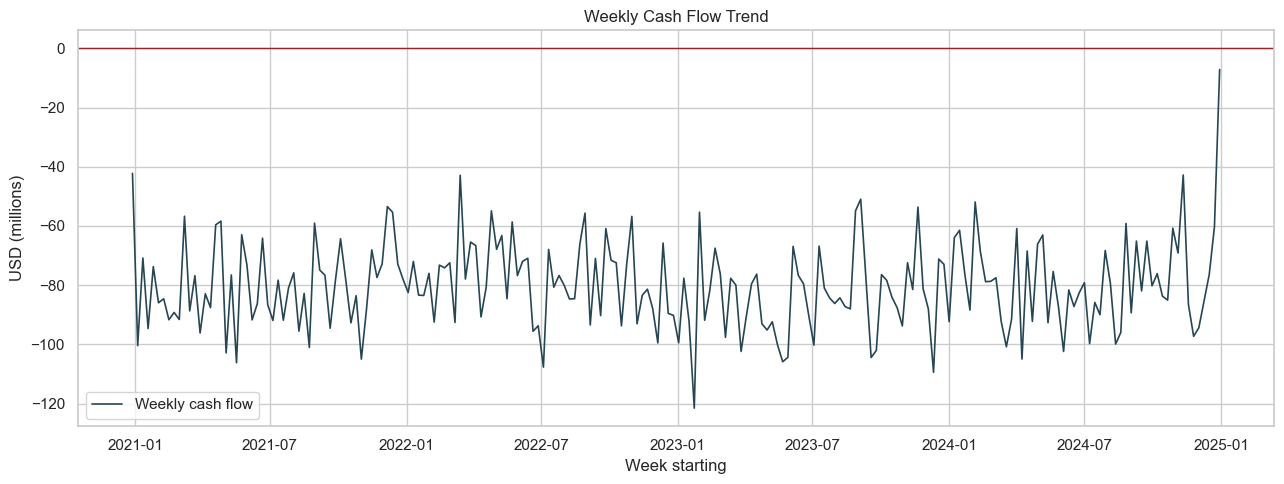

In [4]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(weekly.index, weekly.cash_flow_usd/1e6, color='#264653', lw=1.2, label='Weekly cash flow')
ax.axhline(0, color='#9b2226', lw=1)
ax.set(title='Weekly Cash Flow Trend', ylabel='USD (millions)', xlabel='Week starting')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'01_weekly_cash_flow_trend.png', dpi=180); plt.show()

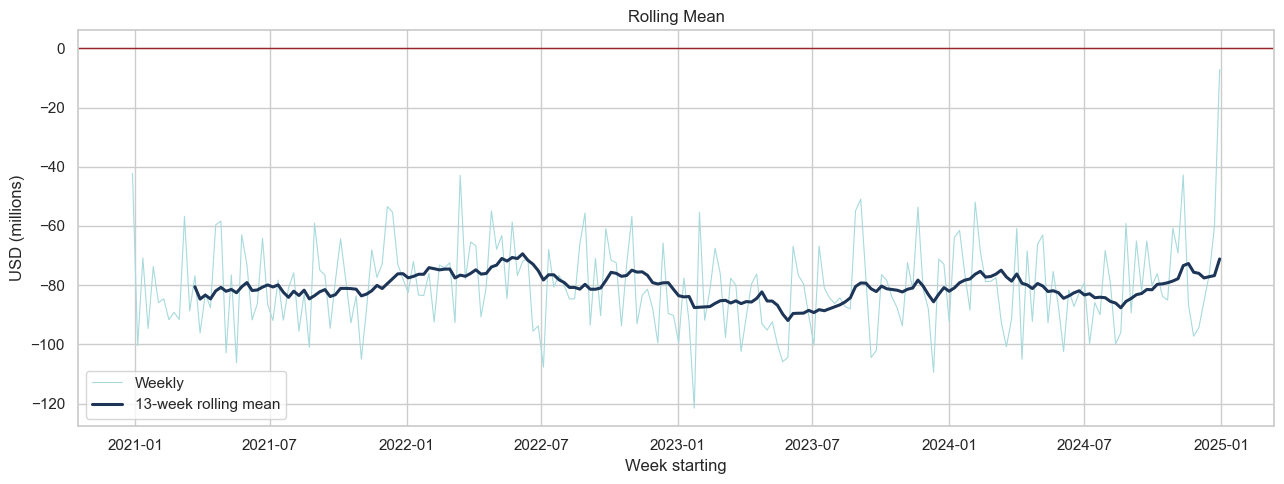

In [5]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(weekly.index, weekly.cash_flow_usd/1e6, color='#a8dadc', lw=.8, label='Weekly')
ax.plot(weekly.index, weekly.rolling_mean_13w/1e6, color='#1d3557', lw=2.2, label='13-week rolling mean')
ax.axhline(0, color='#9b2226', lw=1)
ax.set(title='Rolling Mean', ylabel='USD (millions)', xlabel='Week starting')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'02_rolling_mean.png', dpi=180); plt.show()

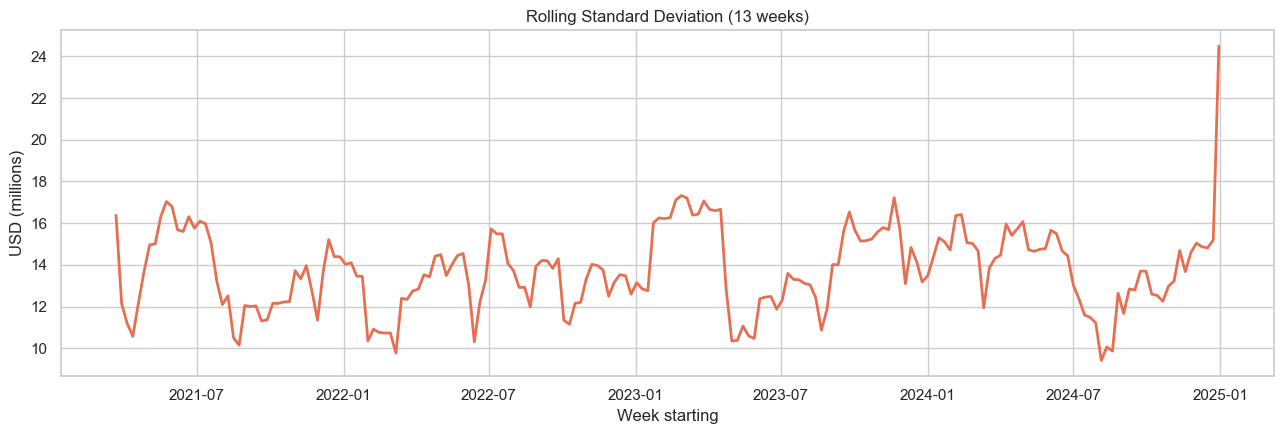

In [6]:
fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(weekly.index, weekly.rolling_std_13w/1e6, color='#e76f51', lw=2)
ax.set(title='Rolling Standard Deviation (13 weeks)', ylabel='USD (millions)', xlabel='Week starting')
fig.tight_layout(); fig.savefig(FIG/'03_rolling_standard_deviation.png', dpi=180); plt.show()

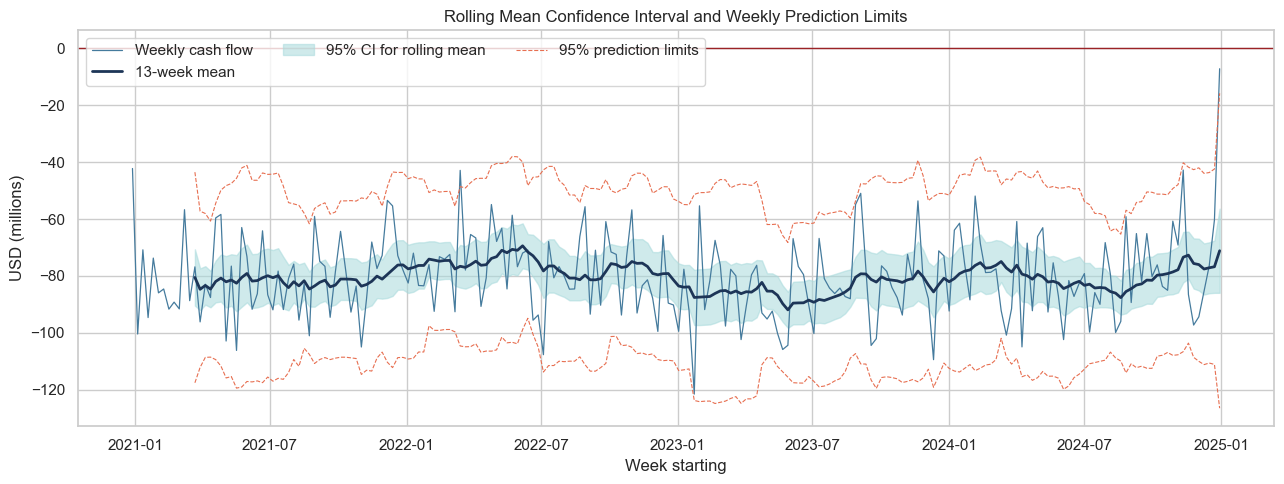

In [7]:
fig, ax = plt.subplots(figsize=(13,5))
x = weekly.index
ax.plot(x, weekly.cash_flow_usd/1e6, color='#457b9d', lw=.9, label='Weekly cash flow')
ax.plot(x, weekly.rolling_mean_13w/1e6, color='#1d3557', lw=2, label='13-week mean')
ax.fill_between(x, weekly.ci95_lower_mean/1e6, weekly.ci95_upper_mean/1e6, color='#a8dadc', alpha=.55, label='95% CI for rolling mean')
ax.plot(x, weekly.pi95_lower/1e6, color='#e76f51', lw=.8, ls='--', label='95% prediction limits')
ax.plot(x, weekly.pi95_upper/1e6, color='#e76f51', lw=.8, ls='--')
ax.axhline(0, color='#9b2226', lw=1)
ax.set(title='Rolling Mean Confidence Interval and Weekly Prediction Limits', ylabel='USD (millions)', xlabel='Week starting')
ax.legend(ncol=3); fig.tight_layout(); fig.savefig(FIG/'04_confidence_interval_bands.png', dpi=180); plt.show()

## 3. Treasury stress detection

In [8]:
# The threshold uses only information available before each week, preventing look-ahead bias.
STRESS_LOOKBACK = 52
weekly['trailing_stress_threshold'] = weekly.cash_flow_usd.shift(1).rolling(STRESS_LOOKBACK, min_periods=STRESS_LOOKBACK).quantile(.10)
weekly['stress_eligible'] = weekly.trailing_stress_threshold.notna()
weekly['stress'] = weekly.stress_eligible & (weekly.cash_flow_usd <= weekly.trailing_stress_threshold)
weekly['stress_reason'] = np.select(
    [~weekly.stress_eligible, weekly.stress],
    ['insufficient-history', 'below-prior-52w-p10'],
    default='normal'
)
stress = weekly[weekly.stress].copy()
stress['severity_rank'] = stress.cash_flow_usd.rank(method='min')
print(f'Eligible weeks: {weekly.stress_eligible.sum()} | Stress weeks: {weekly.stress.sum()}')
display(stress.nsmallest(15,'cash_flow_usd')[['cash_flow_usd','trailing_stress_threshold','rolling_std_13w','stress_reason']])

Eligible weeks: 158 | Stress weeks: 20


,cash_flow_usd,trailing_stress_threshold,rolling_std_13w,stress_reason
week_start,,,,
2023-01-23,-1.215718e+08,-9.371097e+07,1.602364e+07,below-prior-52w-p10
2023-12-11,-1.094621e+08,-1.018908e+08,1.483718e+07,below-prior-52w-p10
2022-07-04,-1.077067e+08,-9.363886e+07,1.572428e+07,below-prior-52w-p10
2023-05-22,-1.058834e+08,-9.930084e+07,1.059912e+07,below-prior-52w-p10
2024-04-08,-1.049717e+08,-1.007804e+08,1.595872e+07,below-prior-52w-p10
2023-09-18,-1.044573e+08,-1.000971e+08,1.564358e+07,below-prior-52w-p10
2023-05-29,-1.043980e+08,-9.952655e+07,1.047390e+07,below-prior-52w-p10
2024-06-03,-1.024093e+08,-9.961760e+07,1.566119e+07,below-prior-52w-p10
2023-03-27,-1.024023e+08,-9.541259e+07,1.706718e+07,below-prior-52w-p10


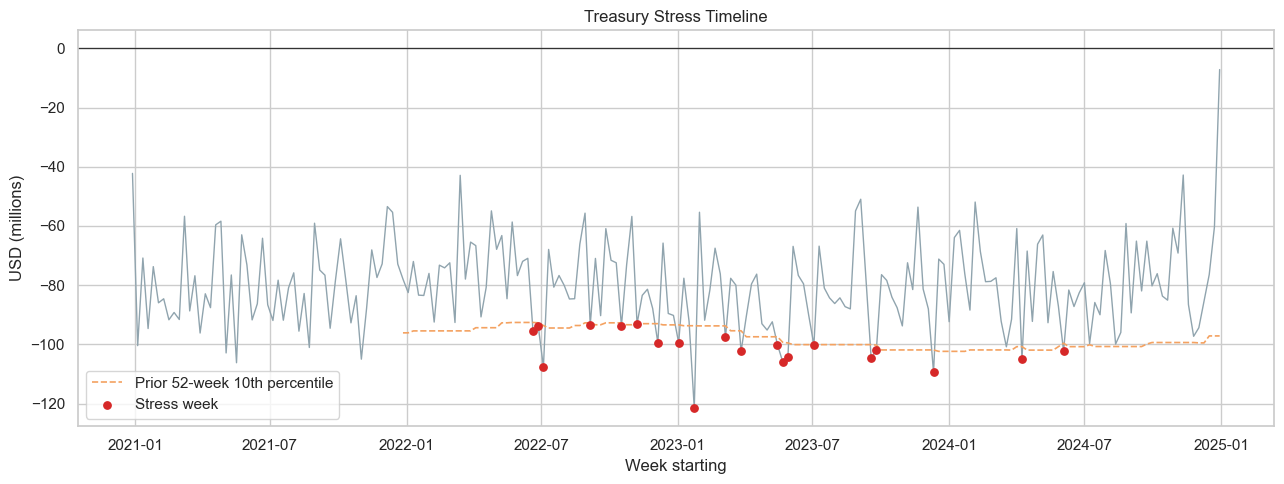

In [9]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(weekly.index, weekly.cash_flow_usd/1e6, color='#90a4ae', lw=1)
ax.plot(weekly.index, weekly.trailing_stress_threshold/1e6, color='#f4a261', lw=1.2, ls='--', label='Prior 52-week 10th percentile')
ax.scatter(stress.index, stress.cash_flow_usd/1e6, color='#d62828', s=28, label='Stress week', zorder=3)
ax.axhline(0, color='#333', lw=.9)
ax.set(title='Treasury Stress Timeline', ylabel='USD (millions)', xlabel='Week starting')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'05_treasury_stress_timeline.png', dpi=180); plt.show()

## 4. Seasonal pattern analysis

In [10]:
weekly['iso_week'] = weekly.index.isocalendar().week.astype(int)
weekly['month'] = weekly.index.month
seasonal = weekly.groupby('iso_week').cash_flow_usd.agg(['mean','median','std','count'])
month_seasonal = weekly.groupby('month').cash_flow_usd.agg(['mean','median','std','count'])
# Week-of-year ANOVA is interpreted cautiously because each group has few annual repeats.
groups = [g.cash_flow_usd.dropna().values for _,g in weekly.groupby('iso_week') if g.cash_flow_usd.notna().sum() >= 2]
anova = stats.f_oneway(*groups)
month_groups = [g.cash_flow_usd.dropna().values for _,g in weekly.groupby('month')]
month_test = stats.kruskal(*month_groups)
acf52 = weekly.cash_flow_usd.autocorr(lag=52)
lb = acorr_ljungbox(weekly.cash_flow_usd.dropna(), lags=[13,26,52], return_df=True)
print(f'Week-of-year ANOVA p-value: {anova.pvalue:.4f}')
print(f'Month Kruskal-Wallis p-value: {month_test.pvalue:.4f}')
print(f'Lag-52 autocorrelation: {acf52:.3f}')
display(lb)
display(month_seasonal)

Week-of-year ANOVA p-value: 0.7148
Month Kruskal-Wallis p-value: 0.8296
Lag-52 autocorrelation: -0.069


,lb_stat,lb_pvalue
13,10.311970,0.668246
26,13.978243,0.973286
52,37.857268,0.929247


,mean,median,std,count
month,,,,
1,-8.240319e+07,-8.251139e+07,1.575268e+07,19
2,-7.869473e+07,-7.877715e+07,1.088867e+07,16
3,-8.286543e+07,-8.870843e+07,1.615802e+07,17
4,-7.728090e+07,-7.960877e+07,1.480511e+07,17
5,-8.364453e+07,-8.459178e+07,1.632373e+07,19
6,-8.301512e+07,-8.445293e+07,1.082107e+07,16
7,-8.431772e+07,-8.263602e+07,1.132514e+07,18
8,-7.969831e+07,-8.354896e+07,1.499729e+07,18
9,-7.984270e+07,-7.865221e+07,1.469010e+07,17


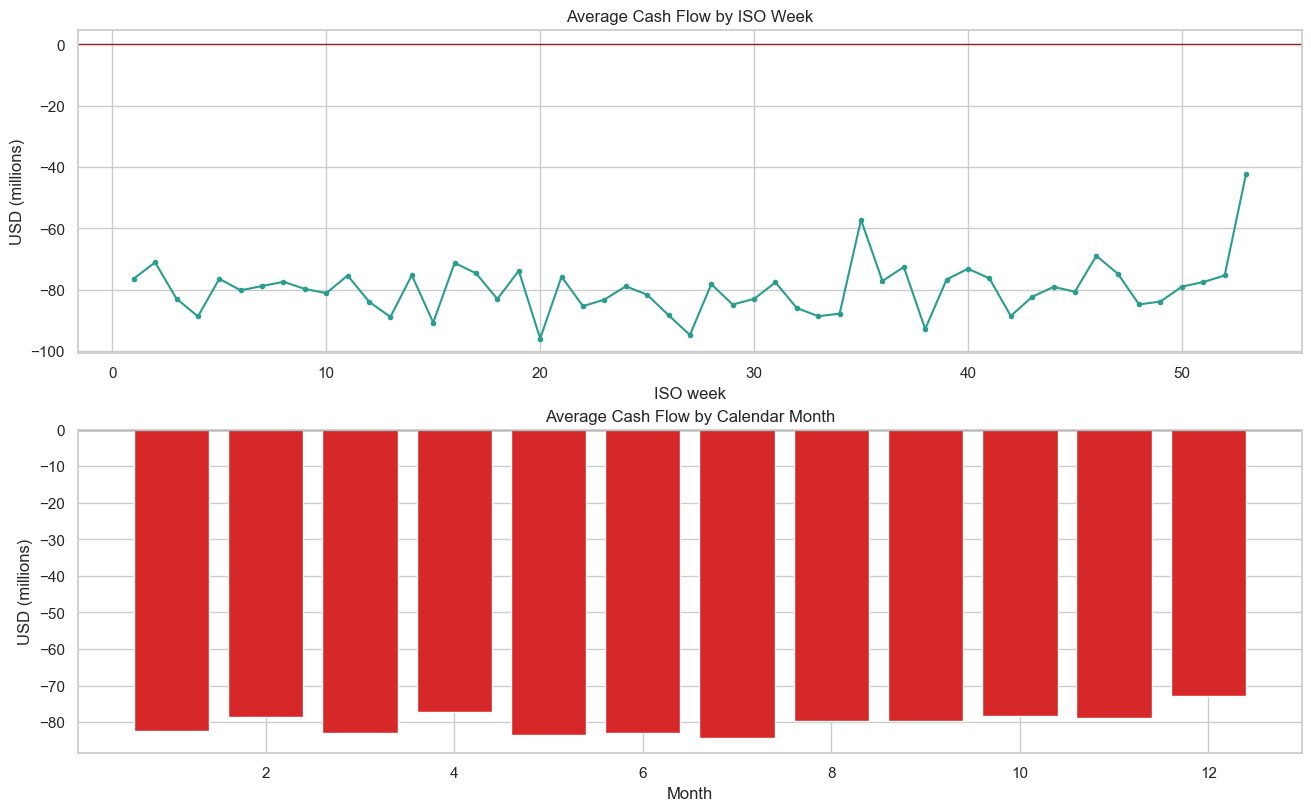

In [11]:
fig, axes = plt.subplots(2,1,figsize=(13,8), constrained_layout=True)
axes[0].plot(seasonal.index, seasonal['mean']/1e6, marker='o', ms=3, color='#2a9d8f')
axes[0].axhline(0,color='#9b2226',lw=1); axes[0].set(title='Average Cash Flow by ISO Week', ylabel='USD (millions)', xlabel='ISO week')
axes[1].bar(month_seasonal.index, month_seasonal['mean']/1e6, color=['#d62828' if v<0 else '#457b9d' for v in month_seasonal['mean']])
axes[1].axhline(0,color='#333',lw=1); axes[1].set(title='Average Cash Flow by Calendar Month', ylabel='USD (millions)', xlabel='Month')
fig.savefig(FIG/'06_seasonal_pattern_analysis.png', dpi=180); plt.show()

## 5. Business activities associated with shortages

In [12]:
activity_cols = ['revenue_usd','procurement_cost_usd','logistics_cost_usd','operational_cost_usd','sla_penalty_usd','transactions','avg_dso','avg_dpo','avg_cash_conversion_cycle']
eligible_weekly = weekly[weekly.stress_eligible].copy()
comparison = eligible_weekly.groupby('stress')[activity_cols].mean().reindex([False, True]).T
comparison.columns = ['normal_week_mean','stress_week_mean']
comparison['stress_vs_normal_pct'] = (comparison.stress_week_mean/comparison.normal_week_mean-1)*100
display(comparison.sort_values('stress_vs_normal_pct'))

# Transaction mix: share of weekly records by activity.
mix = df.groupby(['week_start','transaction_type']).size().unstack(fill_value=0)
mix = mix.div(mix.sum(axis=1), axis=0)
mix = mix.join(weekly[['stress','stress_eligible']])
mix_comparison = mix[mix.stress_eligible].drop(columns='stress_eligible').groupby('stress').mean().reindex([False, True]).T
mix_comparison.columns = ['normal_share','stress_share']
mix_comparison['percentage_point_change'] = (mix_comparison.stress_share-mix_comparison.normal_share)*100
display(mix_comparison.sort_values('percentage_point_change'))

,normal_week_mean,stress_week_mean,stress_vs_normal_pct
revenue_usd,6.356034e+06,5.994315e+06,-5.690955
avg_cash_conversion_cycle,3.515827e+01,3.492036e+01,-0.676670
avg_dso,5.801068e+01,5.793777e+01,-0.125671
avg_dpo,6.789688e+01,6.817945e+01,0.416177
transactions,3.131159e+02,3.251000e+02,3.827355
procurement_cost_usd,2.198652e+06,2.306885e+06,4.922687
logistics_cost_usd,1.416040e+05,1.489907e+05,5.216420
sla_penalty_usd,2.418338e+05,2.601157e+05,7.559705
operational_cost_usd,1.519582e+05,1.700545e+05,11.908696


,normal_share,stress_share,percentage_point_change
Revenue,0.305121,0.272096,-3.302447
Interest Expense,0.029153,0.029486,0.033308
Logistics Cost,0.118971,0.120249,0.127853
SLA Penalty,0.050907,0.054192,0.328529
COGS,0.198543,0.204376,0.583234
Operational Expense,0.098661,0.106938,0.827707
Procurement,0.198644,0.212662,1.401816


## 6. Executive answers and exports

In [13]:
worst = weekly.nsmallest(10,'cash_flow_usd').copy()
weak_months = month_seasonal.nsmallest(3,'mean').index.tolist()
top_associations = comparison['stress_vs_normal_pct'].abs().nlargest(4).index.tolist()
summary = {
    'weeks_analyzed': int(weekly.cash_flow_usd.notna().sum()),
    'stress_weeks': int(weekly.stress.sum()),
    'stress_rate_eligible_weeks': float(weekly.loc[weekly.stress_eligible, 'stress'].mean()),
    'worst_week': str(worst.index[0].date()),
    'worst_week_cash_flow_usd': float(worst.cash_flow_usd.iloc[0]),
    'forecast_interval_coverage': float(coverage),
    'average_interval_width_usd': float(mean_width),
    'seasonality_anova_pvalue': float(anova.pvalue),
    'seasonality_month_kruskal_pvalue': float(month_test.pvalue),
    'lag52_autocorrelation': float(acf52),
    'weakest_months': weak_months,
    'largest_activity_associations': top_associations,
}
print(json.dumps(summary, indent=2))
weekly.to_csv(OUT/'weekly_treasury_metrics.csv')
stress.to_csv(OUT/'treasury_stress_weeks.csv')
comparison.to_csv(OUT/'stress_activity_comparison.csv')
mix_comparison.to_csv(OUT/'stress_transaction_mix.csv')
month_seasonal.to_csv(OUT/'monthly_seasonality.csv')
seasonal.to_csv(OUT/'weekly_seasonality.csv')
(OUT/'analysis_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

{
  "weeks_analyzed": 210,
  "stress_weeks": 20,
  "stress_rate_eligible_weeks": 0.12658227848101267,
  "worst_week": "2023-01-23",
  "worst_week_cash_flow_usd": -121571825.6,
  "forecast_interval_coverage": 0.934010152284264,
  "average_interval_width_usd": 61890645.21092157,
  "seasonality_anova_pvalue": 0.7147809951919566,
  "seasonality_month_kruskal_pvalue": 0.8295897391985708,
  "lag52_autocorrelation": -0.0686630527784729,
  "weakest_months": [
    7,
    5,
    6
  ],
  "largest_activity_associations": [
    "operational_cost_usd",
    "sla_penalty_usd",
    "revenue_usd",
    "logistics_cost_usd"
  ]
}


618

### Interpretation guide

- **Most vulnerable weeks:** use the red stress markers. Each threshold is based only on the preceding 52 weeks, so the flag can be reproduced as an operational early warning; it is not proof of insolvency.
- **Seasonality:** require converging evidence from the week-of-year test, lag-52 autocorrelation, and recurring monthly/week profiles. A single low month is insufficient.
- **Activities and shortages:** stress/normal differences are associations, not causal effects. They identify operational areas for treasury investigation.
- **Uncertainty:** the shaded band is a confidence interval for the rolling mean. The dashed limits and empirical coverage describe uncertainty for an individual future week. Wide or under-covering prediction intervals imply that point forecasts should be paired with liquidity buffers.

### Limitations

The dataset contains transaction-level cash-flow observations but no explicit bank-balance reconciliation, payment due dates, or causal event labels. Weekly sums may include simulated or accounting cash-flow values rather than settled bank movements. Results should therefore be reconciled to treasury ledgers before setting funding limits.